In [40]:
import sys, os
from typing import Tuple, NamedTuple
os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"

import torch
from torch import Tensor, nn, optim  # For Optimizer
from torch.nn.utils import spectral_norm
from torch.utils.data import DataLoader  # For Data Loader
from torch.utils.tensorboard import SummaryWriter  # For Tensor Board Visualisation
from torchvision import transforms, datasets, utils  # For Data Set, Image Transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt  

In [41]:
directories_to_create = [
    "model",               # Where your .pth weights go
    "runs/GAN_MNIST",      # Where your TensorBoard logs go
    "progression_images"   # Where your fixed-noise grids go (if saving locally)
]

# Create them safely
for directory in directories_to_create:
    os.makedirs(directory, exist_ok=True)

print("Directories verified/created.")

Directories verified/created.


In [42]:
# Hyperparameters
# TTUR Learning Rates
learning_rate_discriminator = 2e-4 
learning_rate_generator = 2e-4     
batch_size = 128  # Batch size
num_epochs = 100
log_step = 625  # the number of steps to log the images and losses to tensorboard

latent_dimension = 128  # 64, 128, 256
# for simplicity we will flatten the image to a vector and to use simple MLP networks
# 28 * 28 * 1 flattens to 784
# you are also free to use CNNs
image_dimension = 28 * 28 * 1  # 784

In [43]:
# Select device to train on, we use GPU if available, otherwise we use CPU
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

# we define a transform that converts the image to tensor and normalizes it with mean and std of 0.5
# which will convert the image range from [0, 1] to [-1, 1]
myTransforms = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# the MNIST dataset is available through torchvision.datasets
print("loading MNIST digits dataset")
# let's create a dataloader to load the data in batches
loader = DataLoader(
    datasets.MNIST(root="dataset/", transform=myTransforms, download=True), 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=4,       # Background CPU loading threads
    pin_memory=True      # Bypasses CPU memory management for direct-to-GPU transfers
    # persistent_workers=True,   # NEW: Keeps CPU workers alive between epochs
    # prefetch_factor=4          # NEW: Queues up 4 batches per worker (16 total)
)

Using cuda device
loading MNIST digits dataset


In [44]:
# class Generator(nn.Module):
#     """
#     Generator Model
#     """

#     def __init__(self):
#         super().__init__()
#         self.gen = nn.Sequential( # pyright: ignore
#             nn.Linear(latent_dimension, 256), #TODO define a suitable hidden dimension # pyright: ignore[reportArgumentType]
#             nn.LeakyReLU(0.2), #TODO define a suitable network architecture for the generator
#             nn.Linear(256, 512),
#             nn.LeakyReLU(0.2),
#             nn.Linear(512, 1024),
#             nn.LeakyReLU(0.2),
#             nn.Linear(1024, image_dimension),
#             nn.Tanh(),  # It is helpful to use the tanh activation function to force the output into the [-1,1] range that our normalized images have.
#         )

#     def forward(self, x):
#         return self.gen(x)


# class Discriminator(nn.Module):
#     """
#     Discriminator Model
#     """

#     def __init__(self):
#         super().__init__()
#         self.disc = nn.Sequential( # pyright: ignore
#             nn.Linear(image_dimension, 512), #TODO define a suitable hidden dimension # pyright: ignore[reportArgumentType]
#             nn.LeakyReLU(0.2),
#             nn.Dropout(0.3),
#             nn.Linear(512, 256),
#             nn.LeakyReLU(0.2),
#             nn.Dropout(0.3),
#             nn.Linear(256, 1),

#         )

#     def forward(self, x):
#         x = x.view(-1, image_dimension)
#         return self.disc(x)

In [45]:
# class GeneratorCNN(nn.Module):
#     """
#     Convolutional Generator (Artifact-Free DCGAN)
#     """
#     def __init__(self, latent_dim=128):
#         super().__init__()
        
#         self.fc = nn.Sequential(
#             nn.Linear(latent_dim, 128 * 7 * 7, bias=False),
#             nn.BatchNorm1d(128 * 7 * 7),
#             nn.ReLU(True)
#         )
        
#         self.conv_blocks = nn.Sequential(
#             # Input shape after reshaping: (128, 7, 7)
            
#             # Upsample 1: 7x7 -> 14x14
#             nn.Upsample(scale_factor=2, mode='nearest'),
#             nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False),
#             nn.BatchNorm2d(64),
#             nn.ReLU(True),
            
#             # Upsample 2: 14x14 -> 28x28
#             nn.Upsample(scale_factor=2, mode='nearest'),
#             nn.Conv2d(in_channels=64, out_channels=1, kernel_size=3, stride=1, padding=1, bias=False),
#             nn.Tanh()  # Output range [-1, 1]
#         )

#     def forward(self, x):
#         # Pass through linear layers and activations
#         x = self.fc(x)
        
#         # Reshape into a 3D feature map
#         x = x.view(-1, 128, 7, 7)
        
#         return self.conv_blocks(x)


# class DiscriminatorCNN(nn.Module):
#     """
#     Convolutional Discriminator (DCGAN)
#     Evaluates a 28x28 image and outputs a single real/fake logit.
#     """
#     def __init__(self):
#         super().__init__()
        
#         self.conv_blocks = nn.Sequential(
#             # Input size: (1, 28, 28)
#             # Downsample 1: 28x28 -> 14x14
#             nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Dropout2d(0.3),
            
#             # Downsample 2: 14x14 -> 7x7
#             nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1, bias=False),
#             nn.BatchNorm2d(128),
#             nn.LeakyReLU(0.2, inplace=True),
#             nn.Dropout2d(0.3),
#         )
        
#         # Flatten the 7x7 feature maps and output a single score
#         self.fc = nn.Sequential(
#             nn.Linear(128 * 7 * 7, 1)
#             # No Sigmoid here because you are already using BCEWithLogitsLoss!
#         )

#     def forward(self, x):
#         # Ensure input is shaped as an image (just in case)
#         x = x.view(-1, 1, 28, 28)
        
#         # Pass through convolutions
#         x = self.conv_blocks(x)
        
#         # Flatten to 1D for the linear classification layer
#         x = x.view(x.shape[0], -1) 
#         return self.fc(x)

In [46]:
class GeneratorCNN(nn.Module):
    """
    Standard DCGAN Generator
    """
    def __init__(self, latent_dim=128):
        super().__init__()
        
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7, bias=False),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(True)
        )
        
        self.conv_blocks = nn.Sequential(
            # Input shape: (128, 7, 7)
            
            # Upsample 1: 7x7 -> 14x14
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            # Upsample 2: 14x14 -> 28x28
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()  # Output range [-1, 1]
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 128, 7, 7)
        return self.conv_blocks(x)


class DiscriminatorCNN(nn.Module):
    """
    Spectrally Normalized, 3-Layer Discriminator
    """
    def __init__(self):
        super().__init__()
        
        self.conv_blocks = nn.Sequential(
            # Downsample 1: 28x28 -> 14x14
            spectral_norm(nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Downsample 2: 14x14 -> 7x7
            spectral_norm(nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Downsample 3: 7x7 -> 3x3 (New layer for deeper feature extraction)
            spectral_norm(nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=0, bias=False)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        
        self.fc = nn.Sequential(
            # Flatten 256 channels of 3x3 grids into a single node
            spectral_norm(nn.Linear(256 * 3 * 3, 1))
        )

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = self.conv_blocks(x)
        x = x.view(x.shape[0], -1) 
        return self.fc(x)

In [47]:
# initialize networks and optimizers
# discriminator = Discriminator().to(device)
# generator = Generator().to(device)
def weights_init(m):
    """Custom weights initialization called on Generator and Discriminator."""
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Apply it after you instantiate your models!
generator = GeneratorCNN(latent_dimension).to(device)
discriminator = DiscriminatorCNN().to(device)

generator.apply(weights_init)
discriminator.apply(weights_init)


# Standard GAN Adam betas are (0.5, 0.999) rather than the default (0.9, 0.999)
opt_discriminator = optim.Adam(discriminator.parameters(), lr=learning_rate_discriminator, betas=(0.5, 0.999))
opt_generator = optim.Adam(generator.parameters(), lr=learning_rate_generator, betas=(0.5, 0.999))

# BCEWithLogitsLoss is far more numerically stable than BCELoss + Sigmoid
criterion = nn.BCEWithLogitsLoss()

# initialize tensorboard writer
writer = SummaryWriter(f"runs/GAN_MNIST")


In [ ]:
# Create a folder to save your progression frames
os.makedirs("progression_images", exist_ok=True)
os.makedirs("runs/GAN_MNIST", exist_ok=True)
os.makedirs("report_images", exist_ok=True)


# Generate FIXED noise to track the exact same 16 latent vectors over time.

num_progression_images = 16
fixed_noise = torch.randn(num_progression_images, latent_dimension, device=device)
# Training Loop
step = 0
print("Started Training and visualization...")

# Initialize the gradient scaler for mixed precision
scaler = torch.amp.GradScaler('cuda')

for epoch in range(num_epochs):
    print()
    for batch_idx, (real, _) in enumerate(loader):
        real = real.to(device)
        batch_size = real.shape[0]

        # ==========================================
        # Step 1) Generate fake images
        # ==========================================
        noise = torch.randn(batch_size, latent_dimension).to(device)
        
        # Cast the generator forward pass to FP16
        with torch.amp.autocast('cuda'):
            fake = generator(noise)

        # ==========================================
        # Step 2) Train Discriminator
        # ==========================================
        opt_discriminator.zero_grad()  

        # Cast discriminator forward passes and loss calcs to FP16
        with torch.amp.autocast('cuda'):
            # Real Images
            disc_real = discriminator(real).view(-1) 

            real_labels = torch.ones_like(disc_real) * 0.9   # Label Smoothing
            lossD_real = criterion(disc_real, real_labels)

            # Fake Images (detach to prevent backpropping into the Generator here)
            disc_fake = discriminator(fake.detach()).view(-1)
            fake_labels = torch.zeros_like(disc_fake)
            lossD_fake = criterion(disc_fake, fake_labels)

            loss_discriminator = (lossD_real + lossD_fake) / 2

        # Unscale gradients and update weights

        scaler.scale(loss_discriminator).backward()
        scaler.step(opt_discriminator)

        # ==========================================
        # Step 3) Train Generator
        # ==========================================
        for _ in range(2): # <--- ADD THIS LOOP
            opt_generator.zero_grad()  

            # We need to generate NEW fake images for the second pass
            # so we don't just calculate the exact same gradient twice
            noise = torch.randn(batch_size, latent_dimension).to(device)
            
            with torch.amp.autocast('cuda'):
                fake_double = generator(noise)
                output = discriminator(fake_double).view(-1)
                loss_generator = criterion(output, torch.ones_like(output))

            scaler.scale(loss_generator).backward()
            scaler.step(opt_generator)
            scaler.update()

        # ==========================================
        # Step 4)  Log Progress
        # ==========================================
        # Updates the scale for the next iteration


        # print the progress
        print(
            f"\rEpoch [{epoch+1}/{num_epochs}] Batch {batch_idx}/{len(loader)}, Loss discriminator: {loss_discriminator:.4f}, loss generator: {loss_generator:.4f}",  
            end="",
        )

        # Log the losses and example images to tensorboard
        if batch_idx % log_step == 0:
            with torch.no_grad():
                # 1. SET TO EVALUATION MODE
                generator.eval()
                
                # Generate noise via Generator, we always use the same noise to see the progression
                # Also run the evaluation generation in autocast!
                with torch.amp.autocast('cuda'):
                    fake_eval = generator(fixed_noise).reshape(-1, 1, 28, 28)  
                
                # 2. SET BACK TO TRAINING MODE IMMEDIATELY AFTER
                generator.train()
                
                # Get real data
                data = real.reshape(-1, 1, 28, 28)
                
                # make grid of pictures and add to tensorboard
                # Convert to float32 explicitly before sending to torchvision to avoid tensorboard warnings
                img_grid_fake = utils.make_grid(fake_eval.float(), normalize=True)
                img_grid_real = utils.make_grid(data.float(), normalize=True)

                writer.add_scalar("Loss/Discriminator", loss_discriminator.item(), step)
                writer.add_scalar("Loss/Generator", loss_generator.item(), step)
                writer.add_image("Images/Fake", img_grid_fake, step)
                writer.add_image("Images/Real", img_grid_real, step)

                # increment step
                step += 1
            with torch.no_grad():
                    # 1. Switch to eval mode (Crucial so BatchNorm doesn't distort the image)
                    generator.eval()
                    
                    # 2. Generate the images using autocast
                    with torch.amp.autocast('cuda'):
                        fake_eval = generator(fixed_noise)
                        
                    # 3. Switch back to train mode for the next epoch
                    generator.train()
            
                # 4. Save the batch of 16 images as a single 4x4 grid PNG
            image_filename = f"report_images/epoch_{epoch+1:03d}.png"
            vutils.save_image(
                fake_eval.float(),       # Convert to float32 for safe saving
                image_filename, 
                nrow=4,                  # 4 columns wide
                normalize=True,          # Automatically scales pixel values correctly
                value_range=(-1, 1)      # Tells the function your generator outputs Tanh [-1, 1]
            )
            
            print(f"\nSaved report image: {image_filename}")
            

# create directory model to save the generator and discriminator models
os.makedirs("model", exist_ok=True)

torch.save(generator.state_dict(), "model/generator.pth")
torch.save(discriminator.state_dict(), "model/discriminator.pth")

Started Training and visualization...

Epoch [1/100] Batch 0/469, Loss discriminator: 0.8331, loss generator: 0.8171
Saved report image: report_images/epoch_001.png
Epoch [1/100] Batch 468/469, Loss discriminator: 0.2287, loss generator: 3.4313
Epoch [2/100] Batch 0/469, Loss discriminator: 0.2436, loss generator: 2.4923
Saved report image: report_images/epoch_002.png
Epoch [2/100] Batch 468/469, Loss discriminator: 0.2554, loss generator: 2.4286
Epoch [3/100] Batch 0/469, Loss discriminator: 0.2546, loss generator: 2.2029
Saved report image: report_images/epoch_003.png
Epoch [3/100] Batch 468/469, Loss discriminator: 0.3329, loss generator: 2.6944
Epoch [4/100] Batch 0/469, Loss discriminator: 0.2751, loss generator: 2.2060
Saved report image: report_images/epoch_004.png
Epoch [4/100] Batch 468/469, Loss discriminator: 0.2155, loss generator: 2.2182
Epoch [5/100] Batch 0/469, Loss discriminator: 0.2237, loss generator: 2.5847
Saved report image: report_images/epoch_005.png
Epoch [5/10

In [ ]:
@torch.no_grad()
def test_discriminator_fooling_rate(generator, discriminator, num_samples=1000, batch_size=32):
    """
    Measures how effectively the generator fools the discriminator.
    Target: Around 40% - 60% indicates a well-balanced equilibrium.
    """
    generator.eval()
    discriminator.eval()
    
    fooled_count = 0
    total_samples = 0
    
    num_batches = (num_samples + batch_size - 1) // batch_size
    
    for _ in range(num_batches):
        # Generate fake images
        noise = torch.randn(batch_size, latent_dimension).to(device)
        fake = generator(noise)
        
        # Get discriminator logits and pass through sigmoid (since we used BCEWithLogitsLoss)
        logits = discriminator(fake).view(-1)
        probabilities = torch.sigmoid(logits)
        
        # Count how many fake images were predicted as Real (prob > 0.5)
        fooled_count += (probabilities > 0.5).sum().item()
        total_samples += batch_size

    fooling_rate = (fooled_count / total_samples) * 100
    print(f"--- Evaluation: Discriminator Fooling Rate ---")
    print(f"Generator fooled the Discriminator on {fooling_rate:.2f}% of samples.\n")
    return fooling_rate

@torch.no_grad()
def test_generation_diversity(generator, num_samples=1000):
    """
    Calculates the standard deviation across generated pixels to detect mode collapse.
    Target: A healthy standard deviation (typically > 0.4 for normalized MNIST). 
            Values near 0 indicate mode collapse.
    """
    generator.eval()
    
    # Generate a large batch of images
    noise = torch.randn(num_samples, latent_dimension).to(device)
    fake = generator(noise) # Shape: (num_samples, 784)
    
    # Calculate variance and standard deviation across the batch dimension
    pixel_variance = torch.var(fake, dim=0)
    mean_std = torch.sqrt(pixel_variance).mean().item()
    
    print(f"--- Evaluation: Generation Diversity ---")
    print(f"Average Pixel Standard Deviation: {mean_std:.4f}")
    if mean_std < 0.1:
        print("WARNING: Low diversity detected! The model might be experiencing mode collapse.")
    else:
        print("Pass: Images show healthy pixel-level diversity.")
    print()
    return mean_std

@torch.no_grad()
def save_deterministic_samples(generator, output_path="evaluation_sample.png"):
    """
    Generates a deterministic grid of images using a fixed seed.
    Allows for visual comparison between different training runs or hyperparameter adjustments.
    """
    generator.eval()
    
    # Use a fixed CPU generator seed for perfect reproducibility
    rng = torch.Generator(device='cpu').manual_seed(42)
    fixed_noise = torch.randn(64, latent_dimension, generator=rng).to(device)
    
    # Generate and reshape
    fake = generator(fixed_noise).reshape(-1, 1, 28, 28)
    
    # Create grid and save to disk
    grid = utils.make_grid(fake, nrow=8, normalize=True)
    utils.save_image(grid, output_path)
    print(f"--- Evaluation: Visual Quality ---")
    print(f"Saved deterministic evaluation grid to: {output_path}\n")

@torch.no_grad()
def visualize_accepted_vs_rejected(generator, discriminator, num_samples=256):
    """
    Generates images and splits them into two grids: 
    those that fooled the discriminator and those that were caught.
    """
    generator.eval()
    discriminator.eval()
    
    # 1. Generate images
    noise = torch.randn(num_samples, latent_dimension).to(device)
    fake_images = generator(noise)
    
    # 2. Score with discriminator
    logits = discriminator(fake_images).view(-1)
    probs = torch.sigmoid(logits)  # Convert logits to probabilities
    
    # 3. Create boolean masks for filtering
    accepted_mask = probs > 0.5
    rejected_mask = probs <= 0.5
    
    # 4. Filter and reshape back to image dimensions
    accepted_images = fake_images[accepted_mask].view(-1, 1, 28, 28)
    rejected_images = fake_images[rejected_mask].view(-1, 1, 28, 28)
    
    print(f"Total Generated: {num_samples}")
    print(f"Accepted (Fooled D): {len(accepted_images)} ({len(accepted_images)/num_samples * 100:.1f}%)")
    print(f"Rejected (Caught by D): {len(rejected_images)} ({len(rejected_images)/num_samples * 100:.1f}%)\n")
    
    # 5. Plotting side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Plot up to 16 Accepted images
    if len(accepted_images) > 0:
        acc_grid = vutils.make_grid(accepted_images[:16], nrow=4, normalize=True).cpu()
        axes[0].imshow(acc_grid.permute(1, 2, 0))
    else:
        axes[0].text(0.5, 0.5, 'No images fooled Discriminator', ha='center', va='center')
    axes[0].set_title(f"Accepted (Looks 'Real' to Discriminator)")
    axes[0].axis('off')
        
    # Plot up to 16 Rejected images
    if len(rejected_images) > 0:
        rej_grid = vutils.make_grid(rejected_images[:16], nrow=4, normalize=True).cpu()
        axes[1].imshow(rej_grid.permute(1, 2, 0))
    else:
        axes[1].text(0.5, 0.5, 'None rejected', ha='center', va='center')
    axes[1].set_title(f"Rejected (Caught as Fake)")
    axes[1].axis('off')
        
    plt.tight_layout()
    plt.show()


RUNNING FINAL MODEL EVALUATION TESTS

--- Evaluation: Discriminator Fooling Rate ---
Generator fooled the Discriminator on 0.49% of samples.

--- Evaluation: Generation Diversity ---
Average Pixel Standard Deviation: 0.3834
Pass: Images show healthy pixel-level diversity.

--- Evaluation: Visual Quality ---
Saved deterministic evaluation grid to: final_gan_output.png

Total Generated: 256
Accepted (Fooled D): 0 (0.0%)
Rejected (Caught by D): 256 (100.0%)



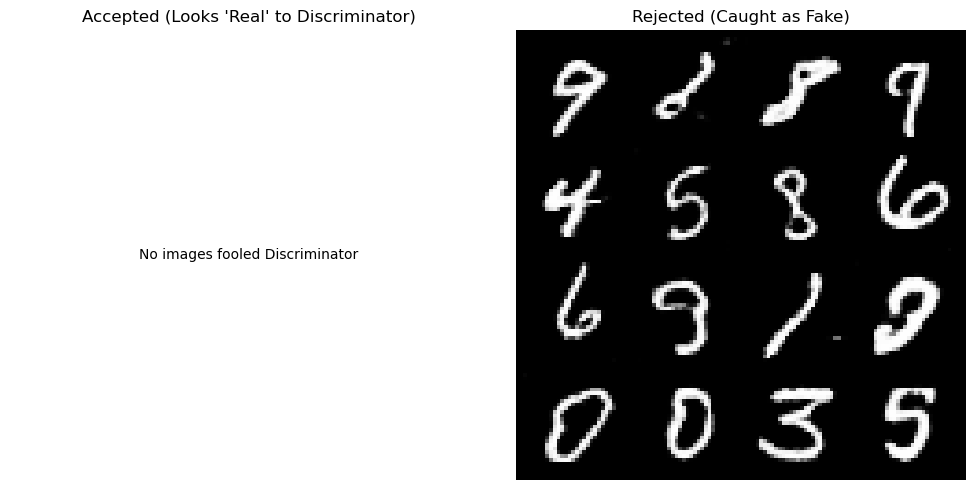

In [ ]:
# Pin models to evaluation mode
generator.eval()
discriminator.eval()

print("\n==========================================")
print("RUNNING FINAL MODEL EVALUATION TESTS")
print("==========================================\n")

# Run Test 1
test_discriminator_fooling_rate(generator, discriminator)

# Run Test 2
test_generation_diversity(generator)

# Run Test 3
save_deterministic_samples(generator, output_path="final_gan_output.png")

visualize_accepted_vs_rejected(generator, discriminator)